In [1]:
import os
import warnings

warnings.filterwarnings("ignore")  # avoid printing out absolute pYaths

In [2]:
def convert_data_type(df, time_cols=[], float_cols = [], cat_cols = []):
    for col in time_cols:
        df[col] = pd.to_datetime(df[col], format = '%Y-%m-%d')
    for col in float_cols:
        df[col] = df[col].astype(float)
    for col in cat_cols:
        df[col] = df[col].astype('category')
    return df

In [3]:
time_cols = ['time']
float_cols = ['open', 'high', 'low', 'close', 'volume']
cat_cols = ['symbol']

In [3]:
from vnstock import Listing
company_list = Listing(source='vci')
cp_list = company_list.symbols_by_group('VN30')


In [4]:

import pandas as pd
from vnstock import Quote
from tqdm import tqdm
df = pd.DataFrame()
start_date = '2025-11-28'
end_date = '2025-12-28'
for company in tqdm(cp_list,desc="extract source"):
    try: 
        quote = Quote(symbol=company, source='vci')
        data = quote.history(start=start_date, end=end_date, interval='1m')
        data['symbol'] = company
        df = pd.concat([df, data], axis=0)
    except:
        continue


extract source: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:09<00:00,  3.04it/s]


In [5]:
df.head()

,time,open,high,low,close,volume,symbol
0,2025-11-04 10:42:00,25.70,25.70,25.65,25.65,30600,ACB
1,2025-11-04 10:43:00,25.70,25.70,25.70,25.70,17400,ACB
2,2025-11-04 10:44:00,25.65,25.65,25.65,25.65,43500,ACB
3,2025-11-04 10:45:00,25.60,25.65,25.60,25.65,12100,ACB
4,2025-11-04 10:46:00,25.65,25.70,25.65,25.65,36700,ACB


In [6]:
today = datetime.now(vietnamese_timezone).strftime("%Y-%m-%d")
quote = Quote(symbol='ACB', source="vci")
df = quote.history(
    start='2025-12-31',
    end='2025-12-31',
    interval="1m"
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 781 entries, 0 to 780
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    781 non-null    datetime64[ns]
 1   open    781 non-null    float64       
 2   high    781 non-null    float64       
 3   low     781 non-null    float64       
 4   close   781 non-null    float64       
 5   volume  781 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 36.7 KB


In [24]:
from datetime import datetime
from zoneinfo import ZoneInfo
import pandas as pd
from datetime import timedelta
vietnamese_timezone = ZoneInfo("Asia/Ho_Chi_Minh")

def fetch_1m(symbol):
    today = datetime.now(vietnamese_timezone).strftime("%Y-%m-%d")
    try:
        end_dt = datetime.now(vietnamese_timezone)
        start_dt = end_dt - timedelta(days=1)

        start = start_dt.strftime("%Y-%m-%d")
        end = end_dt.strftime("%Y-%m-%d")
        quote = Quote(symbol=symbol, source="vci")
        df = quote.history(
            start=start,
            end=end,
            interval="1m"
        )

        if df is None or df.empty:
            return None
        df["time"] = pd.to_datetime(df["time"])
        return df
    except Exception as e:
        return None

In [25]:
acb = fetch_1m("ACB")
acb.tail()

,time,open,high,low,close,volume
386,2025-12-31 14:26:00,23.95,24.00,23.95,24.00,50100
387,2025-12-31 14:27:00,24.00,24.05,23.95,24.05,78400
388,2025-12-31 14:28:00,24.05,24.05,24.00,24.05,45100
389,2025-12-31 14:29:00,24.05,24.05,24.00,24.00,44200
390,2025-12-31 14:45:00,24.00,24.00,24.00,24.00,1166300


In [26]:
def rollup(df_1m, rule):
    df = df_1m.copy()
    df = df.set_index("time")

    rolled = (
        df
        .resample(rule, label="right", closed="right")
        .agg({
            "open": "first",
            "high": "max",
            "low": "min",
            "close": "last",
            "volume": "sum",
        })
        .dropna()
        .tail(300)
        .reset_index()
    )

    return rolled


In [48]:
df_copy = df.set_index("time")

In [52]:
df_copy.groupby("symbol").resample('1min', label="right", closed="right").agg({"open": "first","high": "max","low": "min","close": "last","volume": "sum",}).dropna().reset_index()


,time,open,high,low,close,volume
0,2025-09-22 13:28:00,67.40,67.4,67.40,67.40,200
1,2025-09-22 13:29:00,67.30,67.3,67.30,67.30,1300
2,2025-09-22 13:30:00,67.30,67.3,67.30,67.30,100
3,2025-09-22 13:31:00,67.30,67.3,67.30,67.30,100
4,2025-09-22 13:32:00,67.20,67.3,67.20,67.30,6400
...,...,...,...,...,...,...
13898,2025-12-26 14:26:00,23.90,208.2,16.25,31.65,1708600
13899,2025-12-26 14:27:00,23.90,208.2,16.25,31.65,2011500
13900,2025-12-26 14:28:00,23.85,208.2,16.25,31.60,2843200
13901,2025-12-26 14:29:00,23.95,208.2,16.25,31.50,2594000


In [27]:
import tqdm
ROLLUP_RULES = {
    "1m": "1min",
    "5m": "5min",
    "15m": "15min",
    "30m": "30min",
    "1H": "1h",
}
for cp in tqdm.tqdm(cp_list):
    df_1m = fetch_1m(cp)

    if df_1m is None or df_1m.empty:
        continue
    for screener, rule in ROLLUP_RULES.items():
        rolled = rollup(df_1m, rule)
        print(rolled)

  3%|███▌                                                                                                      | 1/30 [00:00<00:10,  2.66it/s]

                   time   open   high    low  close   volume
0   2025-12-30 13:13:00  24.05  24.05  24.05  24.05    16000
1   2025-12-30 13:14:00  24.05  24.10  24.05  24.10    17000
2   2025-12-30 13:15:00  24.05  24.05  24.05  24.05     2000
3   2025-12-30 13:16:00  24.05  24.10  24.05  24.10    11700
4   2025-12-30 13:17:00  24.10  24.10  24.05  24.05     4700
..                  ...    ...    ...    ...    ...      ...
295 2025-12-31 14:26:00  23.95  24.00  23.95  24.00    50100
296 2025-12-31 14:27:00  24.00  24.05  23.95  24.05    78400
297 2025-12-31 14:28:00  24.05  24.05  24.00  24.05    45100
298 2025-12-31 14:29:00  24.05  24.05  24.00  24.00    44200
299 2025-12-31 14:45:00  24.00  24.00  24.00  24.00  1166300

[300 rows x 6 columns]
                  time   open   high    low  close   volume
0  2025-12-30 10:15:00  24.10  24.15  24.10  24.10    27100
1  2025-12-30 10:20:00  24.10  24.15  24.05  24.05    86500
2  2025-12-30 10:25:00  24.05  24.05  24.00  24.05    54100
3  2

  7%|███████                                                                                                   | 2/30 [00:01<00:14,  1.91it/s]

                   time  open  high   low  close  volume
0   2025-12-29 09:22:00  59.0  59.0  59.0   59.0     100
1   2025-12-29 09:23:00  59.1  59.6  58.8   59.6    3800
2   2025-12-29 09:24:00  59.6  59.6  58.9   59.0    5400
3   2025-12-29 09:25:00  59.0  59.0  59.0   59.0     400
4   2025-12-29 09:26:00  59.0  59.0  59.0   59.0     200
..                  ...   ...   ...   ...    ...     ...
295 2025-12-31 14:25:00  61.5  61.5  61.5   61.5    1500
296 2025-12-31 14:26:00  61.5  61.5  61.5   61.5    1200
297 2025-12-31 14:27:00  61.5  61.6  61.5   61.5    1100
298 2025-12-31 14:29:00  61.1  61.1  61.0   61.0     300
299 2025-12-31 14:45:00  61.8  61.8  61.8   61.8   36500

[300 rows x 6 columns]
                   time  open  high   low  close  volume
0   2025-12-26 11:00:00  59.2  59.2  58.7   59.2    4800
1   2025-12-26 11:05:00  59.1  59.1  59.1   59.1     200
2   2025-12-26 11:10:00  59.1  59.2  59.1   59.2     300
3   2025-12-26 11:15:00  59.2  59.2  59.2   59.2    1100
4   202

 10%|██████████▌                                                                                               | 3/30 [00:01<00:13,  1.93it/s]

...

                   time  open  high   low  close  volume
0   2025-12-30 13:02:00  62.0  62.0  61.9   61.9     600
1   2025-12-30 13:03:00  61.9  62.0  61.9   61.9    4600
2   2025-12-30 13:04:00  62.0  62.0  61.9   61.9   12700
3   2025-12-30 13:05:00  61.9  62.0  61.9   62.0    2600
4   2025-12-30 13:06:00  61.9  61.9  61.8   61.8    1600
..                  ...   ...   ...   ...    ...     ...
295 2025-12-31 14:26:00  61.4  61.4  61.3   61.4   16300
296 2025-12-31 14:27:00  61.4  61.4  61.3   61.3   16700
297 2025-12-31 14:28:00  61.3  61.4  61.3   61.3    6400
298 2025-12-31 14:29:00  61.4  61.4  61.2   61.2   52000
299 2025-12-31 14:45:00  61.2  61.2  61.2   61.2  361000

[300 rows x 6 columns]
                  time  open  high   low  close  volume
0  2025-12-30 10:00:00  61.9  61.9  61.7   61.8   13900
1  2025-12-30 10:05:00  61.8  61.9  61.7   61.8   41600
2  2025-12-30 10:10:00  61.8  61.8  61.7   61.8   75600
3  2025-12-30 10:15:00  61.8  61.8  61.7   61.8   10700
4  2025-12-3

 97%|█████████████████████████████████████████████████████████████████████████████████████████████████████▌   | 29/30 [00:15<00:00,  1.84it/s]

                   time   open   high    low  close   volume
0   2025-12-30 13:16:00  28.50  28.60  28.50  28.55    46700
1   2025-12-30 13:17:00  28.55  28.55  28.50  28.50   138700
2   2025-12-30 13:18:00  28.55  28.55  28.50  28.50     3000
3   2025-12-30 13:19:00  28.50  28.50  28.50  28.50     6100
4   2025-12-30 13:20:00  28.50  28.55  28.50  28.50    24700
..                  ...    ...    ...    ...    ...      ...
295 2025-12-31 14:26:00  28.85  28.95  28.85  28.95   572200
296 2025-12-31 14:27:00  28.95  28.95  28.85  28.85   456300
297 2025-12-31 14:28:00  28.90  28.90  28.75  28.80   149700
298 2025-12-31 14:29:00  28.85  28.85  28.75  28.75    63000
299 2025-12-31 14:45:00  28.65  28.65  28.65  28.65  1731000

[300 rows x 6 columns]
                  time   open   high    low  close   volume
0  2025-12-30 10:15:00  29.00  29.00  28.95  29.00   470700
1  2025-12-30 10:20:00  29.00  29.00  28.85  28.85   862600
2  2025-12-30 10:25:00  28.85  28.85  28.70  28.85  1035700
3  2

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:15<00:00,  1.91it/s]

                   time   open   high    low  close   volume
0   2025-12-30 13:16:00  32.35  32.40  32.35  32.35    49400
1   2025-12-30 13:17:00  32.35  32.35  32.25  32.25    61300
2   2025-12-30 13:18:00  32.25  32.30  32.15  32.15   110700
3   2025-12-30 13:19:00  32.20  32.20  32.10  32.15    41700
4   2025-12-30 13:20:00  32.15  32.15  32.05  32.05    75800
..                  ...    ...    ...    ...    ...      ...
295 2025-12-31 14:26:00  33.40  33.45  33.35  33.45   110200
296 2025-12-31 14:27:00  33.45  33.45  33.35  33.35    39700
297 2025-12-31 14:28:00  33.35  33.35  33.30  33.30    55400
298 2025-12-31 14:29:00  33.30  33.35  33.25  33.25    68300
299 2025-12-31 14:45:00  33.65  33.65  33.65  33.65  1837400

[300 rows x 6 columns]
                  time   open   high    low  close   volume
0  2025-12-30 10:15:00  32.50  32.55  32.45  32.45    26000
1  2025-12-30 10:20:00  32.45  32.55  32.45  32.50    43700
2  2025-12-30 10:25:00  32.55  32.55  32.45  32.45    64000
3  2

NameError: name 'rolled' is not defined

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257430 entries, 0 to 8580
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   time    257430 non-null  datetime64[ns]
 1   open    257430 non-null  float64       
 2   high    257430 non-null  float64       
 3   low     257430 non-null  float64       
 4   close   257430 non-null  float64       
 5   volume  257430 non-null  int64         
 6   symbol  257430 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 15.7+ MB


In [10]:
def resample_to_daily(group):
  resampled_group = group.resample('D').agg({
      'open': 'first',
      'high': 'max',
      'low': 'min',
      'close': 'last',
      'volume': 'sum'
  }).dropna()
  return resampled_group

In [11]:
# df = convert_data_type(df, time_cols, float_cols, cat_cols)
# df.set_index("time", inplace=True)

# # Apply the resampling function to each group
# df_daily = df.groupby('symbol').apply(resample_to_daily).reset_index()
# df_daily["stock_median_volume"] = df_daily.groupby("symbol")["volume"].transform("median").astype(int)
# df_daily["stock_average_price"] = df_daily.groupby("symbol")["close"].transform("mean")
# df_daily["stock_average_nominal_volume"] = df_daily["stock_median_volume"] * df_daily["stock_average_price"]
# top_100_symbols = df_daily.groupby("symbol")['stock_average_nominal_volume'].median().nlargest(10).index
# # Filter the DataFrame to keep only the top 100 stocks by nominal volum
# df_daily = df_daily[df_daily['symbol'].isin(list(top_100_symbols))]
# df = df[df['symbol'].isin(list(top_100_symbols))]
# print(f"Number of total one minute bars after resampling: {df.shape[0]}")
# print(f"Symbols: {df_daily.symbol.unique()}")

In [12]:
df.set_index("time", inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 257430 entries, 2025-11-04 10:42:00 to 2025-12-26 14:45:00
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   open    257430 non-null  float64
 1   high    257430 non-null  float64
 2   low     257430 non-null  float64
 3   close   257430 non-null  float64
 4   volume  257430 non-null  int64  
 5   symbol  257430 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 13.7+ MB


In [13]:
from vnstock import Company
company = Company(symbol='ACB', source='VCI')

In [14]:
company.overview().history[0]

' - Ngày 24/04/1993: Ngân hàng Thương mại Cổ phần Á Châu (ACB) được thành lập với vốn điều lệ ban đầu là 20 tỷ đồng theo Giấy phép số 0032/NH-GP của Ngân hàng Nhà nước;  - Ngày 17/02/1996: Tăng vốn điều lệ lên 341 tỷ đồng;  - Năm 2005: Tăng vốn điều lệ lên 948,32 tỷ đồng;  - Ngày 14/02/2006: Tăng vốn điều lệ lên lên 1.100 tỷ đồng;  - Ngày 31/10/2006: Niêm yết trên Sở Giao dịch Chứng khoán Hà Nội (HNX);  - Ngày 21/11/2006: Giao dịch trên Sở Giao dịch Chứng khoán Hà Nội (HNX);  - Ngày 25/05/2007: Tăng vốn điều lệ lên 2.530 tỷ đồng;  - Năm 2007: Thành lập công ty cho thuê tài chính ACB;  - Năm 2011: Khai trương Trung tâm dữ dạng mô-dun theo tiêu chuẩn quốc tế đầu tiên tại Việt Nam;  - Năm 2014: Nâng cấp hệ nghiệp vụ ngân hàng lõi từ TCBS sang DNA;  - Ngày 09/01/2017: Tăng vốn điều lệ lên 10.273.238.960.000 đồng;  - Ngày 30/11/2018: Tăng vốn điều lệ lên 12.885.877.380.000 đồng;  - Ngày 15/11/2019: Tăng vốn điều lệ lên 16.627.372.770.000 đồng.  - Ngày 19/10/2020: Tăng vốn điều lệ lên 21.615

In [15]:
!pip3 install tqdm


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [16]:
import json
from tqdm import tqdm
fundamental_data = {}
maybe_delisted=[]
for symbol in tqdm(df["symbol"].unique(), desc="Fetching fundamental data..."):
    company = Company(symbol=symbol, source='VCI')
    try:
        company_info = company.overview()
        fundamental_data[symbol] = {
            "Loai_cty" : [str(company_info.icb_name3[0]), 
                          str(company_info.icb_name2[0]), 
                          str(company_info.icb_name4[0])],
            "Tong_co_phieu" : int(company_info['issue_share'][0]),
            "Von_dieu_le" : int(company_info['charter_capital'][0])
        }
    except Exception as e:
        maybe_delisted.append(stock)
        continue
        
with open("fundamental_data.json", "w",encoding="utf-8") as f:
    json.dump(fundamental_data, f)
df = df[df["symbol"].isin(list(fundamental_data.keys()))]

Fetching fundamental data...: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:16<00:00,  1.81it/s]


### Market Capitalization
Market Capitalization is a key metric that traders use to assess a stock’s size. It is calculated by multiplying the stock price by the total number of shares outstanding. In the intraday dataframe context, I will use the opening price of the day as the stock price to calculate market cap. Then I divide by 1 thousand (cause price are in thousand) to get the market cap in millions.

----
### Vốn hóa thị trường
Vốn hóa thị trường là một chỉ số quan trọng mà các nhà giao dịch sử dụng để đánh giá quy mô của một cổ phiếu. Nó được tính bằng cách nhân giá cổ phiếu với tổng số cổ phiếu đang lưu hành. Trong ngữ cảnh của dataframe giao dịch trong ngày, tôi sẽ sử dụng giá mở cửa trong ngày làm giá cổ phiếu để tính vốn hóa thị trường. Sau đó, tôi chia cho 1 ngàn để có được vốn hóa thị trường tính bằng triệu vnđ.

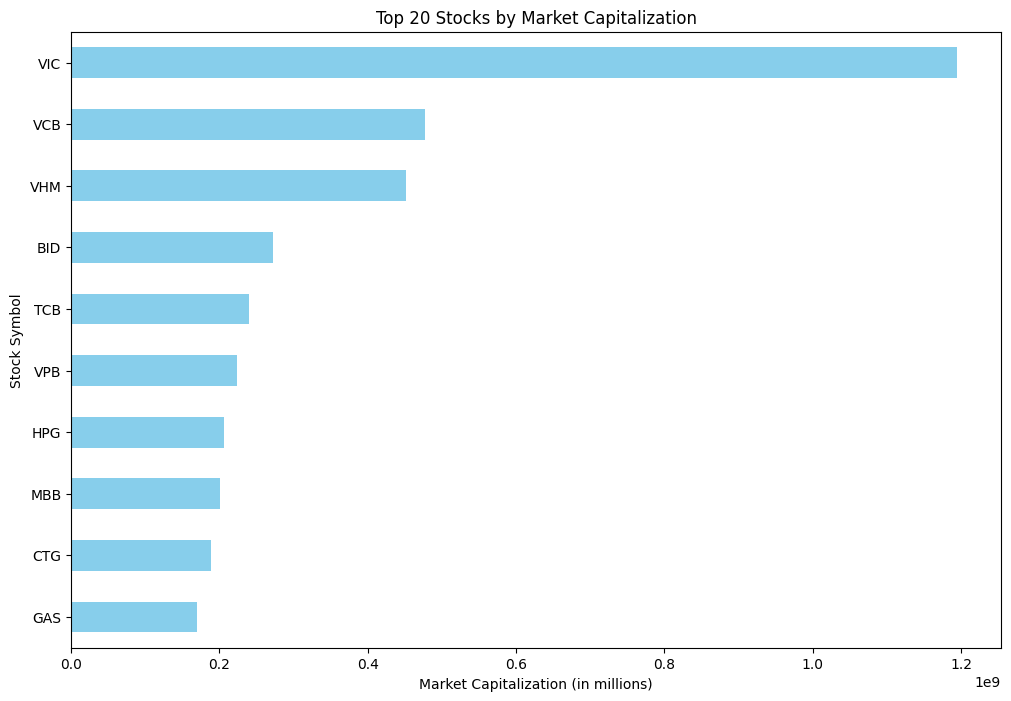

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df["market_cap"] = df.groupby(["symbol", "time"])["open"].transform("first") * df["symbol"].apply(lambda x: fundamental_data[x]["Tong_co_phieu"]).astype(float) / 1_000
top_10_stocks = df.groupby("symbol")["market_cap"].last().nlargest(10)

plt.figure(figsize=(12, 8))
top_10_stocks.sort_values().plot(kind='barh', color='skyblue')
plt.title("Top 20 Stocks by Market Capitalization")
plt.xlabel("Market Capitalization (in millions)")
plt.ylabel("Stock Symbol")
plt.show()

### Volatility
Volatility measures how dramatically a stock’s price swings in either direction. It’s like a stock’s “personality profile”: some stocks are calm and steady, while others are wildly unpredictable. Higher volatility stocks are generally considered riskier, but they’re particularly attractive to day traders because bigger price swings create more opportunities for profit (though also more potential for loss)
To quantify this behavior, we use Historical Volatility, which is calculated by:
- Taking the standard deviation of daily returns
- Normalizing by the opening price
- Annualizing the result (multiplying by √252, the number of trading days in a year)
  
This gives us a standardized way to compare the “nervousness” of different stocks, regardless of their price levels. A stock with 30% annualized volatility tends to move much more dramatically than one with 15% volatility

--------
### Biến động
Biến động đo lường mức độ biến động mạnh của giá cổ phiếu theo cả hai hướng. Nó giống như “hồ sơ tính cách” của cổ phiếu: một số cổ phiếu ổn định và bình lặng, trong khi những cổ phiếu khác lại rất khó đoán. Cổ phiếu có biến động cao thường được coi là rủi ro hơn, nhưng chúng lại đặc biệt hấp dẫn đối với các nhà giao dịch trong ngày vì biến động giá lớn tạo ra nhiều cơ hội kiếm lời hơn (mặc dù cũng tiềm ẩn nhiều rủi ro thua lỗ hơn).
Để định lượng hành vi này, chúng ta sử dụng Biến động Lịch sử, được tính bằng cách:
- Lấy độ lệch chuẩn của lợi nhuận hàng ngày
- Chuẩn hóa theo giá mở cửa
- Quy đổi kết quả thành biến động hàng năm (nhân với √252, số ngày giao dịch trong một năm)

Điều này cung cấp cho chúng ta một cách chuẩn hóa để so sánh “mức độ biến động” của các cổ phiếu khác nhau, bất kể mức giá của chúng. Một cổ phiếu có biến động hàng năm 30% có xu hướng biến động mạnh hơn nhiều so với cổ phiếu có biến động 15%.

In [38]:
import numpy as np
df_daily = df.groupby('symbol').resample('D').agg({
    'close': 'last'
}).dropna()

df_daily['return'] = df_daily.groupby('symbol')['close'].transform(lambda x: np.log(x / x.shift(1)))
# Calculate the rolling standard deviation of the daily returns
window_size = 30 #30days
df_daily['rolling_std'] = df_daily.groupby('symbol')['return'].rolling(window=window_size, min_periods=1).std().reset_index(0, drop=True)
# Annualize the volatility
df_daily['hist_vol'] = (df_daily['rolling_std'] * np.sqrt(252))
df_daily['hist_vol'] = df_daily['hist_vol'].fillna(method='bfill')
# Merge the daily historical volatility back into the original DataFrame
df_daily["symbol"] = df_daily.index.get_level_values(0)
df_daily["time"] = df_daily.index.get_level_values(1)
df_daily = df_daily.reset_index(drop=True)
df_reset = df.reset_index()
df_reset['time'] = pd.to_datetime(df_reset['time']).dt.normalize()
df_daily['time'] = pd.to_datetime(df_daily['time']).dt.normalize()
minute_index = df.index
df= df_reset.merge(df_daily[['symbol', 'time', 'hist_vol']], 
                         on=['symbol','time'], 
                         how='left').set_index(minute_index)

### Average True Range (ATR): Measuring Intraday Volatility
The Average True Range (ATR) is a powerful tool for measuring a stock’s intraday volatility. Unlike standard volatility measures that only look at closing prices, ATR captures the full range of price movement throughout the trading day, making it particularly valuable for day traders.
How ATR Works:
1. First, we calculate the True Range (TR) for each day, which is the greatest of:

- Current high minus current low
- Current high minus previous close
- Previous close minus current low
  
2. Then, the ATR is calculated as a 14-day moving average of these True Range values. The formula accounts for all price gaps and limit moves, providing a comprehensive view of price volatility.

When analyzing ATR:

- Higher ATR values indicate more volatile stocks with larger price swings
- Lower ATR values suggest more stable, predictable price movement
- ATR is typically normalized by dividing by the stock’s price to allow comparison across different price levels
------------------------------------------------------------------------------------------------------------------
### Chỉ số Biên độ Biến động Giá Trung bình (ATR): Đo lường Biến động Giá trong Ngày
Chỉ số Biên độ Biến động Giá Trung bình (ATR) là một công cụ mạnh mẽ để đo lường biến động giá trong ngày của một cổ phiếu. Không giống như các chỉ số biến động tiêu chuẩn chỉ xem xét giá đóng cửa, ATR nắm bắt toàn bộ phạm vi biến động giá trong suốt ngày giao dịch, điều này làm cho nó đặc biệt có giá trị đối với các nhà giao dịch trong ngày.

Cách thức hoạt động của ATR:
1. Đầu tiên, chúng ta tính toán Biên độ Biến động Giá thực (TR) cho mỗi ngày, là giá trị lớn nhất trong các giá trị sau:

- Giá cao nhất hiện tại trừ đi giá thấp nhất hiện tại

- Giá cao nhất hiện tại trừ đi giá đóng cửa trước đó

- Giá đóng cửa trước đó trừ đi giá thấp nhất hiện tại

2. Sau đó, ATR được tính toán bằng cách lấy trung bình động 14 ngày của các giá trị Biên độ Biến động Giá thực này. Công thức này tính đến tất cả các khoảng trống giá và các mức giá giới hạn, cung cấp một cái nhìn toàn diện về biến động giá.

Khi phân tích ATR:

- Giá trị ATR cao hơn cho thấy cổ phiếu biến động mạnh hơn với biên độ biến động giá lớn hơn
- Giá trị ATR thấp hơn cho thấy biến động giá ổn định và dễ dự đoán hơn
- ATR thường được chuẩn hóa bằng cách chia cho giá cổ phiếu để cho phép so sánh giữa các mức giá khác nhau

In [40]:
df.drop(['time'],axis=1,inplace=True)

In [41]:
df

,open,high,low,close,volume,symbol,market_cap,hist_vol
time,,,,,,,,
2025-11-04 10:42:00,25.70,25.70,25.65,25.65,30600,ACB,1.320121e+08,0.041715
2025-11-04 10:43:00,25.70,25.70,25.70,25.70,17400,ACB,1.320121e+08,0.041715
2025-11-04 10:44:00,25.65,25.65,25.65,25.65,43500,ACB,1.317552e+08,0.041715
2025-11-04 10:45:00,25.60,25.65,25.60,25.65,12100,ACB,1.314984e+08,0.041715
2025-11-04 10:46:00,25.65,25.70,25.65,25.65,36700,ACB,1.317552e+08,0.041715
...,...,...,...,...,...,...,...,...
2025-12-26 14:26:00,31.55,31.65,31.50,31.65,69400,VRE,7.347422e+07,0.533147
2025-12-26 14:27:00,31.65,31.75,31.65,31.65,51600,VRE,7.370710e+07,0.533147
2025-12-26 14:28:00,31.65,31.70,31.60,31.60,59300,VRE,7.370710e+07,0.533147


In [48]:
import pandas_ta as ta
df_daily = df.groupby('symbol').resample('D').agg({
    'close': 'last',
    'high': 'max',
    'low': 'min'
}).dropna()
df_daily["symbol"] = df_daily.index.get_level_values(0)
df_daily["time"] = df_daily.index.get_level_values(1)
df_daily = df_daily.reset_index(drop=True)
df_daily["TR"] = ta.true_range(high=df_daily['high'], low=df_daily['low'], close=df_daily['close'])
df_daily["ATR"] = ta.atr(high=df_daily['high'], low=df_daily['low'], close=df_daily['close'], length=14)
df_reset = df.reset_index()
df_reset['time'] = pd.to_datetime(df_reset['time']).dt.normalize()
df_daily['time'] = pd.to_datetime(df_daily['time']).dt.normalize()
minute_index = df.index
df = df_reset.merge(df_daily[['symbol', 'time', 'TR','ATR']], 
                         on=['symbol','time'], 
                         how='left').set_index(minute_index)
df["ATR"] = df["ATR"].fillna(method='bfill')
df["TR"] = df["TR"].fillna(method='bfill')
df["ATR"] = df["ATR"] / df["close"] # Normalize ATR by the stock price
df["TR"] = df["TR"] / df["close"]

In [50]:
df

,time,open,high,low,close,volume,symbol,market_cap,hist_vol,TR,ATR
time,,,,,,,,,,,
2025-11-04 10:42:00,2025-11-04,25.70,25.70,25.65,25.65,30600,ACB,1.320121e+08,0.041715,0.027290,0.013506
2025-11-04 10:43:00,2025-11-04,25.70,25.70,25.70,25.70,17400,ACB,1.320121e+08,0.041715,0.027237,0.013480
2025-11-04 10:44:00,2025-11-04,25.65,25.65,25.65,25.65,43500,ACB,1.317552e+08,0.041715,0.027290,0.013506
2025-11-04 10:45:00,2025-11-04,25.60,25.65,25.60,25.65,12100,ACB,1.314984e+08,0.041715,0.027290,0.013506
2025-11-04 10:46:00,2025-11-04,25.65,25.70,25.65,25.65,36700,ACB,1.317552e+08,0.041715,0.027290,0.013506
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-26 14:26:00,2025-12-26,31.55,31.65,31.50,31.65,69400,VRE,7.347422e+07,0.533147,0.071090,0.058080
2025-12-26 14:27:00,2025-12-26,31.65,31.75,31.65,31.65,51600,VRE,7.370710e+07,0.533147,0.071090,0.058080
2025-12-26 14:28:00,2025-12-26,31.65,31.70,31.60,31.60,59300,VRE,7.370710e+07,0.533147,0.071203,0.058172


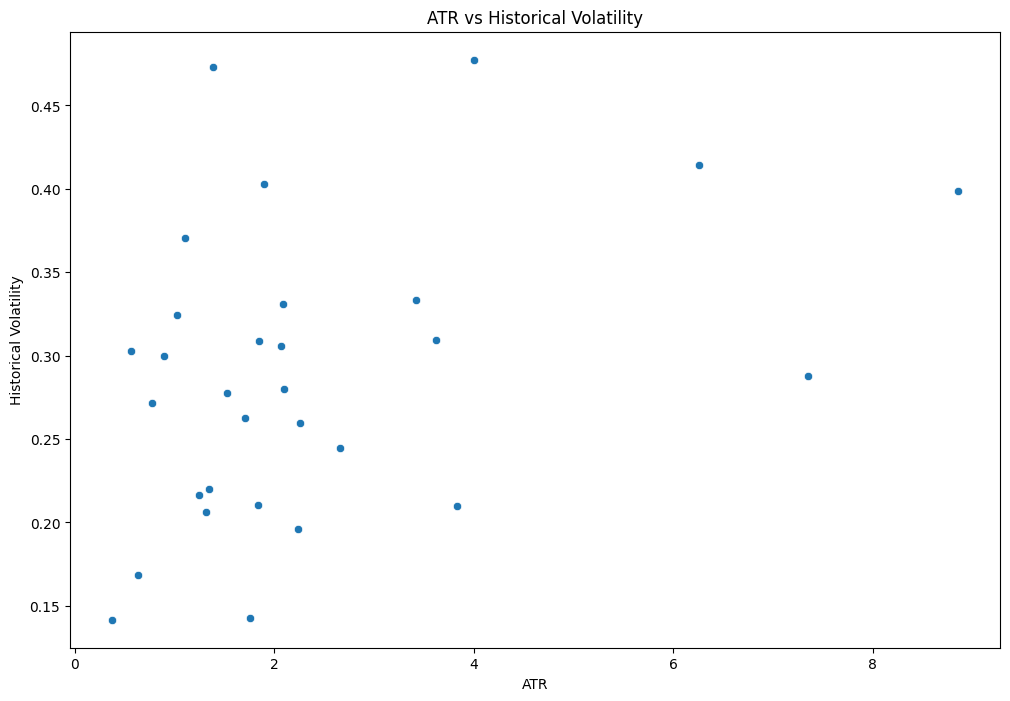

In [52]:
# plot correlation between ATR and hist_vol
data = df_new.groupby("symbol").agg({"hist_vol": "mean", "ATR": "mean"}).dropna()
plt.figure(figsize=(12, 8))
sns.scatterplot(data=data, x="ATR", y="hist_vol")
plt.title("ATR vs Historical Volatility")
plt.xlabel("ATR")
plt.ylabel("Historical Volatility")
plt.show()